<a href="https://colab.research.google.com/github/daria-nishchenko/B4U_Workshops/blob/main/Nishchenko_B4U_Workshop1_Lab4_Copy_of_Intermediate_data_wrangling_hands_on.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Intermediate data wrangling hands-on 4
Практика з обробки даних

In [ ]:
import pandas as pd
import numpy as np

# Hands-on assignment

For our hands on assignment we will be performing data wrangling techniques. This assigmnet is based on a real-world data sample collection by 2 different centers in Ukraine and Romania.
You are provided with 3 files to work with and combine into a single dataframe.
https://drive.google.com/drive/folders/1fvEI70KUf-pwWsXnziodC7ipJs-Dtjf3?usp=share_link

---

Для нашого практичного завдання ми будемо використовувати методи роботи з даними. Це завдання базується на реальних заборах даних, зібраних 2 різними центрами в Україні та Румунії.
Вам буде надано 3 файли для роботи виконання завдань.
https://drive.google.com/drive/folders/1fvEI70KUf-pwWsXnziodC7ipJs-Dtjf3?usp=share_link


## Tentative instructions

1. Explore the data files.
2. Get access to the data in google collab(either upload files or connect to your google drive). Use ChatGPT to learn, how to skip first row of the Excel file.
3. Merge the UA and UA2 datasets into a single datarfame
4. Identify columns that contain similar information but are writted down differently. Pay extra attention to the column names, as they might contain spaces and other hard-to-notice symbols.
5. Develop a strategy to fix the AGE part and Rural\Urban of dataset between Ukrainian and Romainan datafile so the data can be seamlessly merged.
6. Use ChatGPT or Bard to rename the columns between dataframes so they can be added\concatenated (Use GPT to learn how to cocatenate 2 datasets)
7. Produce summary statistics(hint - **describe** the data)
8. Report the number of people above 40 that lived in urban areas total.
9. Produce the same stats for Romania and Ukraine separately.
10. Produce a merged dataframe with normalized Data as result.csv.

---

## Орієнтовні інструкції

1. Ознайомтеся з файлами даних.
2. Отримайте доступ до даних в google collab (завантажте файли, або підключіть до вашого google-диску). Використовуйте ChatGPT, щоб дізнатися, як пропустити перший рядок файлу Excel.
3. Об'єднайте датафрейми UA та UA2 в один датафрейм.
4. Визначте стовпці, які містять схожу інформацію, але записані по-різному. Зверніть увагу на назви стовпців, оскільки вони можуть містити пробіли та інші малопомітні символи.
5. Розробіть стратегію виправлення частини AGE(вік) та Rural\Urban(місто\село) набору даних між українським та румунським файлом даних, щоб їх було об'єднати.
6. Використовуйте ChatGPT або Bard для перейменування стовпців у датафреймах до однакового формату, щоб їх можна було додати\об'єднати (використовуйте GPT, щоб дізнатися, як об'єднати 2 датафрейми).
7. Створіть зведену статистику (підказка - **describe** дані)
8. Підрахуйте загальну кількість людей старше 40 років, які проживають у міських поселеннях.
9. Підготуйте таку ж статистику окремо для Румунії та України.
10. Створіть об'єднаний датафрейм з нормалізованими даними -  result.csv.





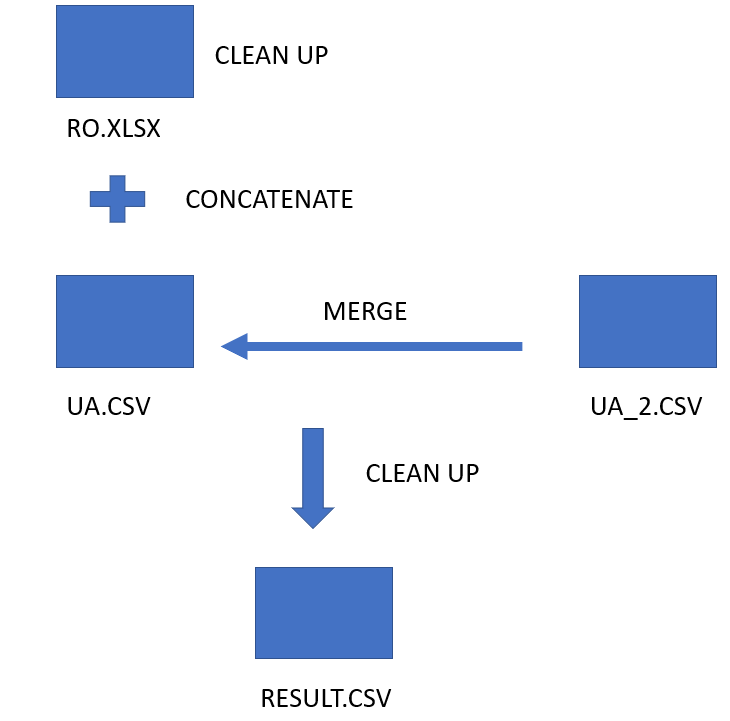

Let's first load the DataFrame with Romanian data and examine the available information.
---

Спочатку завантажимо датафрейм з румунськими даними та розглянемо наявну інформацію.

In [ ]:
RO_df = pd.read_excel('/content/RO.xlsx', skiprows=1)
RO_df

,ID,Nat_RO,Nat_ROHU,Sex_M,Sex_F,Age_18-25,Age_26-30,Age_31-40,Age_41-45,Age_46-50,...,Age_56-60,Age_61-65,Age_65-70,Age_over 70,Part_rural,Part_urban,Par_rural,Par_urban,Gpar_rural,Gp_urban
0,SM1,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN
1,SM2,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN
2,SM3,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN
3,SM4,NaN,1.0,NaN,1.0,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,1.0,NaN
4,SM5,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,1.0,1.0,NaN,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148,MM66,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0
149,MM67,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0
150,MM68,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0
151,MM69,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0


Let's examine the available columns in detail.

---

Детально вивчемо наявні стовпці.

In [ ]:
column_names_list = RO_df.columns.tolist()
print(column_names_list)

['ID', 'Nat_RO', 'Nat_ROHU ', 'Sex_M', 'Sex_F', 'Age_18-25', 'Age_26-30', 'Age_31-40', 'Age_41-45', 'Age_46-50', 'Age_51-55', 'Age_56-60', 'Age_61-65', 'Age_65-70', 'Age_over 70', 'Part_rural ', 'Part_urban ', 'Par_rural ', 'Par_urban ', 'Gpar_rural', 'Gp_urban']


Let's sort the columns of the Romanian dataframe so that we can merge them with the Ukrainian data later on.

---

Упорядкуємо стовпці румунського датафрему, щоб надалі можна було їх об'єднати з українськими даними.

In [ ]:
column_mappings = {
    'nationality': {'columns': ['Nat_RO', 'Nat_ROHU '], 'new_column': 'NAT'},
    'sex': {'columns': ['Sex_M', 'Sex_F'], 'new_column': 'SEX'},
    'age': {'columns': ['Age_18-25', 'Age_26-30', 'Age_31-40', 'Age_41-45', 'Age_46-50', 'Age_51-55', 'Age_56-60', 'Age_61-65' , 'Age_65-70', 'Age_over 70'], 'new_column': 'AGE'},
    'participant': {'columns': ['Part_rural ', 'Part_urban '], 'new_column': 'PART'},
    'parental': {'columns': ['Par_rural ', 'Par_urban '], 'new_column': 'PAR'},
    'grandparental': {'columns': ['Gpar_rural', 'Gp_urban'], 'new_column': 'GRAND'}
}

for mapping in column_mappings.values():
    columns = mapping['columns']
    new_column = mapping['new_column']


    # Apply transformation
    RO_df[new_column] = RO_df[columns].apply(lambda row: row.idxmax().split('_')[1] if row.max() == 1 else None, axis=1)
    RO_df.drop(columns, axis=1, inplace=True)


Let's edit the content of the PART column.

---

Відредагуємо вміст стовпця PART.

In [ ]:
RO_df['PART'] = RO_df['PART'].replace({'urban ': 'urban', 'rural ': 'rural'})
RO_df

,ID,NAT,SEX,AGE,PART,PAR,GRAND
0,SM1,RO,M,46-50,urban,urban,rural
1,SM2,ROHU,F,31-40,rural,rural,rural
2,SM3,ROHU,F,31-40,rural,rural,rural
3,SM4,ROHU,F,41-45,urban,rural,rural
4,SM5,ROHU,F,over 70,urban,rural,rural
...,...,...,...,...,...,...,...
148,MM66,RO,M,61-65,urban,urban,urban
149,MM67,RO,M,65-70,urban,urban,urban
150,MM68,RO,F,46-50,urban,urban,urban
151,MM69,RO,M,over 70,urban,urban,urban


Let's clean the Romanian dataset by removing missing values.

---

Очистимо дані румунського датасету від пропусків.

In [ ]:
nullValue_counts=RO_df.isnull().sum()
nullValue_counts

ID       0
NAT      1
SEX      1
AGE      3
PART     1
PAR      7
GRAND    7
dtype: int64

In [ ]:
NaNsOnly=RO_df.loc[(RO_df['NAT'].isnull() ) | (RO_df['SEX'].isnull() ) | (RO_df['AGE'].isnull() ) | (RO_df['PART'].isnull() ) | (RO_df['PAR'].isnull() ) | (RO_df['GRAND'].isnull() ) ]
RO_df.dropna(subset=['NAT', 'SEX', 'AGE', 'PART', 'PAR', 'GRAND'], inplace=True)

nullValue_counts=RO_df.isnull().sum()
nullValue_counts

ID       0
NAT      0
SEX      0
AGE      0
PART     0
PAR      0
GRAND    0
dtype: int64

Finally, we have obtained an ordered and cleaned dataset for the Romanian data.

---

Нарешті отримуємо впорядкований та очищений датасет для румунських даних.

In [ ]:
RO_df

,ID,NAT,SEX,AGE,PART,PAR,GRAND
0,SM1,RO,M,46-50,urban,urban,rural
1,SM2,ROHU,F,31-40,rural,rural,rural
2,SM3,ROHU,F,31-40,rural,rural,rural
3,SM4,ROHU,F,41-45,urban,rural,rural
4,SM5,ROHU,F,over 70,urban,rural,rural
...,...,...,...,...,...,...,...
148,MM66,RO,M,61-65,urban,urban,urban
149,MM67,RO,M,65-70,urban,urban,urban
150,MM68,RO,F,46-50,urban,urban,urban
151,MM69,RO,M,over 70,urban,urban,urban


Next, we will load the UA and UA2 dataframes and merge them into one dataframe called UA.
---

Далі завантажимо датафрейми UA та UA2, об'єднаємо їх в один - UA.

In [ ]:
UA1_df=pd.read_csv('/content/UA.csv')
UA2_df=pd.read_csv('/content/UA2.csv')
UA_df = UA1_df.merge(UA2_df, on='Record ID', how='outer')

UA_df

,Record ID,Стать,Вік у роках,Де прожив учасник дитинство - в селі чи в місті?,Чи проживає учасник зараз в селі чи в місті?
0,1,Жінка,31.0,Місто,Місто
1,2,Жінка,22.0,Село,Місто
2,3,Чоловік,28.0,Місто,Місто
3,4,Чоловік,26.0,Село,Місто
4,5,Жінка,29.0,Село,Село
...,...,...,...,...,...
1083,11,Чоловік,74.0,Село,Село
1084,12,Чоловік,20.0,NaN,NaN
1085,13,Чоловік,39.0,Село,Місто
1086,21,Чоловік,29.0,Село,Село


Let's examine the available columns in detail.

---

Детально вивчемо наявні стовпці.

In [ ]:
column_names_list = UA_df.columns.tolist()
print(column_names_list)

['Record ID', 'Стать', 'Вік у роках', 'Де прожив учасник дитинство - в селі чи в місті?', 'Чи проживає учасник зараз в селі чи в місті?']


We will order the content of the Ukrainian dataset according to the same template that we used to order the Romanian data.

---

Упорядкуюємо вміст українського датасету відповідно до того шаблону, за яким ми вже впорядкували румунські дані.

In [ ]:
# Rename a variable in a specific cell
UA_df.rename(columns={'Record ID': 'ID', 'Стать': 'SEX', 'Вік у роках': 'AGE', 'Чи проживає учасник зараз в селі чи в місті?': 'PART', 'Де прожив учасник дитинство - в селі чи в місті?': 'PAR'}, inplace=True)

# Rename a variable in a specific cell
UA_df['SEX'] = UA_df['SEX'].replace({'Жінка': 'F', 'Чоловік': 'M'})
UA_df['PART'] = UA_df['PART'].replace({'Місто': 'urban', 'Село': 'rural'})
UA_df['PAR'] = UA_df['PAR'].replace({'Місто': 'urban', 'Село': 'rural'})

UA_df['NAT'] = 'UA'

UA_df = UA_df[['ID', 'NAT', 'SEX', 'AGE', 'PART', 'PAR']]
UA_df

,ID,NAT,SEX,AGE,PART,PAR
0,1,UA,F,31.0,urban,urban
1,2,UA,F,22.0,urban,rural
2,3,UA,M,28.0,urban,urban
3,4,UA,M,26.0,urban,rural
4,5,UA,F,29.0,rural,rural
...,...,...,...,...,...,...
1083,11,UA,M,74.0,rural,rural
1084,12,UA,M,20.0,NaN,NaN
1085,13,UA,M,39.0,urban,rural
1086,21,UA,M,29.0,rural,rural


Cleanse the Ukrainian dataset from missing values.

---

Очистимо дані українського датасету від пропусків.

In [ ]:
nullValue_counts=UA_df.isnull().sum()
nullValue_counts

ID       0
NAT      0
SEX      4
AGE     77
PART    44
PAR     47
dtype: int64

In [ ]:
NaNsOnly=UA_df.loc[(UA_df.loc[:, 'SEX'].isnull() ) | (UA_df.loc[:, 'AGE'].isnull() ) | (UA_df.loc[:, 'PART'].isnull() ) | (UA_df.loc[:, 'PAR'].isnull() )]
UA_df.dropna(subset=['SEX', 'AGE', 'PART', 'PAR'], inplace=True)

nullValue_counts=UA_df.isnull().sum()
nullValue_counts

<ipython-input-68-d45f6788d2c3>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  UA_df.dropna(subset=['SEX', 'AGE', 'PART', 'PAR'], inplace=True)


ID      0
NAT     0
SEX     0
AGE     0
PART    0
PAR     0
dtype: int64

Align the content of the 'AGE' column in the Ukrainian dataset to match the intervals in the Romanian dataset.

---

Упорядкуємо вміст стовпця 'AGE' для українських даних так, щоб він відповідав інтервалам у румунському датасеті.

In [ ]:
# Define the intervals for age groups
age_bins = [18, 25, 30, 40, 45, 50, 55, 60, 65, 70, float('inf')]
age_labels = ['18-25', '26-30', '31-40', '41-45', '46-50', '51-55', '56-60', '61-65', '65-70', 'over 70']

# Convert 'AGE' column to numeric format
UA_df.loc[:, 'AGE'] = pd.to_numeric(UA_df.loc[:, 'AGE'], errors='coerce')

# Apply the cut function to create age groups
UA_df.loc[:, 'AGE'] = pd.cut(UA_df.loc[:, 'AGE'], bins=age_bins, labels=age_labels, right=False)

<ipython-input-69-38c70fc6644d>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  UA_df.loc[:, 'AGE'] = pd.to_numeric(UA_df.loc[:, 'AGE'], errors='coerce')
<ipython-input-69-38c70fc6644d>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  UA_df.loc[:, 'AGE'] = pd.cut(UA_df.loc[:, 'AGE'], bins=age_bins, labels=age_labels, right=False)


Finally, we obtain an ordered and cleaned dataset for the Ukrainian data.

---

Нарешті отримуємо впорядкований та очищений датасет для українських даних.

In [ ]:
UA_df

,ID,NAT,SEX,AGE,PART,PAR
0,1,UA,F,31-40,urban,urban
1,2,UA,F,18-25,urban,rural
2,3,UA,M,26-30,urban,urban
3,4,UA,M,26-30,urban,rural
4,5,UA,F,26-30,rural,rural
...,...,...,...,...,...,...
1082,10,UA,F,65-70,rural,rural
1083,11,UA,M,over 70,rural,rural
1085,13,UA,M,31-40,urban,rural
1086,21,UA,M,26-30,rural,rural


Let's prepare summary statistics separately for the Romanian data.

---

Підготуємо зведену статистику окремо для румунських даних.

In [ ]:
RO_df.describe()

,ID,NAT,SEX,AGE,PART,PAR,GRAND
count,144,144,144,144,144,144,144
unique,144,2,2,10,2,2,2
top,SM1,RO,F,46-50,urban,rural,rural
freq,1,120,77,30,104,105,116


Let's calculate the total number of people over 40 years old living in urban settlements for the Romanian dataset.

---

Підрахуємо загальну кількість людей старше 40 років, які проживають у міських поселеннях, для румунського датасету.

In [ ]:
# Define the desired age ranges
age_ranges = ['41-45', '46-50', '51-55', '56-60', '61-65', '65-70', 'over 70']

# Filter the dataframe based on age ranges and urban residence
filtered_df = RO_df[(RO_df['AGE'].isin(age_ranges)) & (RO_df['PART'] == 'urban')]

# Count the number of unique IDs
total_count = filtered_df['ID'].nunique()

# Print the total number of IDs
print("Total number of IDs matching the criteria: ", total_count)

Total number of IDs matching the criteria:  87


Let's prepare summary statistics separately for the Ukrainian dataset.

---

Підготуємо зведену статистику окремо для українських даних.

In [ ]:
UA_df.describe()

,ID,NAT,SEX,AGE,PART,PAR
count,994,994,994,958,994,994
unique,994,1,2,10,3,3
top,1,UA,F,18-25,urban,rural
freq,1,994,519,254,523,606


Let's calculate the total number of people over 40 years old living in urban settlements for the Ukrainian dataset.

---

Підрахуємо загальну кількість людей старше 40 років, які проживають у міських поселеннях, для українського датасету.

In [ ]:
# Define the desired age ranges
age_ranges = ['41-45', '46-50', '51-55', '56-60', '61-65', '65-70', 'over 70']

# Filter the dataframe based on age ranges and urban residence
filtered_df = UA_df[(UA_df['AGE'].isin(age_ranges)) & (UA_df['PART'] == 'urban')]

# Count the number of unique IDs
total_count = filtered_df['ID'].nunique()

# Print the total number of IDs
print("Total number of IDs matching the criteria: ", total_count)

Total number of IDs matching the criteria:  145


Let's combine the Ukrainian and Romanian datasets. We will also prepare summary statistics for the combined data.
---

Об'єднаємо український та румунський датасети. Також підготуємо зведену статистику для вже об'єднаних даних.

In [ ]:
combined_df = pd.concat([RO_df, UA_df])
combined_df.describe()

,ID,NAT,SEX,AGE,PART,PAR,GRAND
count,1138,1138,1138,1102,1138,1138,144
unique,1138,3,2,10,3,5,2
top,SM1,UA,F,18-25,urban,rural,rural
freq,1,994,596,258,627,606,116


Additionally, let's calculate the total number of people over 40 years old living in urban settlements for the combined dataset.

---

Також підрахуємо загальну кількість людей старше 40 років, які проживають у міських поселеннях, для об'єданого датасету.

In [ ]:
# Define the desired age ranges
age_ranges = ['41-45', '46-50', '51-55', '56-60', '61-65', '65-70', 'over 70']

# Filter the dataframe based on age ranges and urban residence
filtered_df = combined_df[(combined_df['AGE'].isin(age_ranges)) & (combined_df['PART'] == 'urban')]

# Count the number of unique IDs
total_count = filtered_df['ID'].nunique()

# Print the total number of IDs
print("Total number of IDs matching the criteria: ", total_count)

Total number of IDs matching the criteria:  232


Let's save the combined dataframe with normalized data as "result.csv".
---

Збережемо об'єднаний датафрейм з нормалізованими даними як result.csv.

In [ ]:
combined_df.to_csv('Nishchenko_result.csv')